# Notebook 02 — Model Training Analysis

**Mục đích:** Phân tích chi tiết kết quả training model Late Fusion (XLM-R + FT-Transformer).  
**Yêu cầu:** Chạy sau khi `src/train.py` và `scripts/run_ablation.py` đã hoàn thành.

---

## Nội dung
1. Load & kiểm tra results files
2. Learning curves (train loss vs val loss)
3. Confusion matrix (test set)
4. Per-class F1 bar chart
5. Ablation study results table
6. Error analysis — top sai nhiều nhất mỗi lớp
7. LIME explanation examples

In [1]:
import os
from pathlib import Path

# Resolve repo root regardless of where nbconvert starts the kernel
_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent
os.chdir(PROJECT_ROOT)
print(f"PROJECT_ROOT: {PROJECT_ROOT}")


PROJECT_ROOT: /Users/nguyenlephong/Documents/Source/Deep/deep-social-sentiment-analysis


In [2]:
import sys, json
from pathlib import Path

sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score
)

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["joy", "sadness", "anger", "fear", "disgust", "surprise", "neutral"]
PALETTE     = sns.color_palette("husl", len(CLASS_NAMES))

print("Setup OK")

Setup OK


---
## 1. Load Results Files

In [3]:
# ── Training metrics log (written by src/train.py) ────────────────────────
METRICS_LOG = PROJECT_ROOT / "models" / "best_model" / "training_metrics.json"

if METRICS_LOG.exists():
    with open(METRICS_LOG) as f:
        train_history = json.load(f)  # List[{epoch, train_loss, val_loss, val_f1_macro}]
    history_df = pd.DataFrame(train_history)
    print(f"Training history: {len(history_df)} epochs")
    print(history_df.tail())
else:
    print("⚠️  training_metrics.json not found — run src/train.py first")
    # Synthetic placeholder for notebook development
    history_df = pd.DataFrame({
        "epoch":      list(range(1, 11)),
        "train_loss": [1.95, 1.62, 1.41, 1.24, 1.11, 1.01, 0.93, 0.87, 0.83, 0.80],
        "val_loss":   [1.80, 1.55, 1.38, 1.26, 1.18, 1.14, 1.13, 1.14, 1.17, 1.19],
        "val_f1_macro":     [0.30, 0.40, 0.50, 0.57, 0.61, 0.64, 0.65, 0.65, 0.64, 0.63],
    })
    print("Using SYNTHETIC placeholder data — replace with real results after training")

Training history: 7 epochs
   epoch  train_loss  val_loss  val_f1_macro  val_precision_macro  \
2      3      0.9752    0.9924        0.6321               0.6372   
3      4      0.7893    0.9520        0.6562               0.6727   
4      5      0.6340    0.9530        0.6713               0.6723   
5      6      0.5095    0.9676        0.6812               0.6885   
6      7      0.4121    1.0151        0.6797               0.6939   

   val_recall_macro  
2            0.6350  
3            0.6547  
4            0.6735  
5            0.6770  
6            0.6710  


In [4]:
# ── Test set predictions (written by src/evaluate.py) ────────────────────
PREDS_PATH = PROJECT_ROOT / "models" / "best_model" / "test_predictions.csv"

if PREDS_PATH.exists():
    preds_df = pd.read_csv(PREDS_PATH)   # columns: text, true_label, pred_label
    print(f"Test predictions: {len(preds_df)} samples")
    print(preds_df.head(3))
else:
    print("⚠️  test_predictions.csv not found — run src/evaluate.py first")
    # Synthetic placeholder
    rng = np.random.default_rng(42)
    n_test = 266
    true_labels = rng.choice(CLASS_NAMES, n_test,
                             p=[0.30, 0.12, 0.14, 0.11, 0.10, 0.11, 0.12])
    # Simulate ~65% accuracy with confusion
    pred_labels = true_labels.copy()
    noise_idx = rng.choice(n_test, int(n_test * 0.35), replace=False)
    pred_labels[noise_idx] = rng.choice(CLASS_NAMES, len(noise_idx))
    preds_df = pd.DataFrame({
        "text":       [f"sample_{i}" for i in range(n_test)],
        "true_label": true_labels,
        "pred_label": pred_labels,
    })
    print("Using SYNTHETIC placeholder predictions")

Test predictions: 1443 samples
                                                text true_label pred_label
0                             per mệt quá mấy con ơi    sadness    neutral
1  per dạo này bị xàm à [LAUGH_TEARS] [LAUGH_TEAR...    disgust    disgust
2        lưu ý: lịch họp tuần tới, deadline ngày mai    neutral    neutral


In [5]:
# ── Ablation results (Exp1–4 including PhoBERT) ────────────────────────
ABLATION_PATH_EXT = PROJECT_ROOT / "reports" / "ablation_results_with_phobert.csv"
ABLATION_PATH     = PROJECT_ROOT / "reports" / "ablation_results.csv"

if ABLATION_PATH_EXT.exists():
    ablation_df = pd.read_csv(ABLATION_PATH_EXT)
    print("Loaded ablation results WITH PhoBERT (Exp1–4):")
elif ABLATION_PATH.exists():
    ablation_df = pd.read_csv(ABLATION_PATH)
    print("Loaded ablation results (Exp1–3, PhoBERT file not found):")
else:
    print("⚠️  No ablation CSV found — using synthetic placeholder")
    ablation_df = pd.DataFrame({
        "experiment":      ["exp1_xlmr_only", "exp2_xlmr_teencode", "exp3_full_fusion"],
        "f1_macro":        [0.620, 0.657, 0.701],
        "accuracy":        [0.672, 0.705, 0.738],
        "precision_macro": [0.631, 0.665, 0.712],
        "recall_macro":    [0.614, 0.651, 0.692],
    })

# Human-readable display labels
_LABEL_MAP = {
    "exp1_xlmr_only":     "Exp1\nXLM-R only",
    "exp2_xlmr_teencode": "Exp2\nXLM-R+Teencode",
    "exp3_full_fusion":   "Exp3\nFull Fusion",
    "exp4_phobert":       "Exp4\nPhoBERT-v2",
}
ablation_df["display_label"] = ablation_df["experiment"].map(
    lambda e: _LABEL_MAP.get(e, e)
)
print(ablation_df[["experiment", "f1_macro", "accuracy"]].to_string(index=False))


Loaded ablation results WITH PhoBERT (Exp1–4):
        experiment  f1_macro  accuracy
    exp1_xlmr_only  0.623546  0.642379
exp2_xlmr_teencode  0.654833  0.664684
  exp3_full_fusion  0.645414  0.658736
      exp4_phobert  0.718550  0.721190


---
## 2. Learning Curves

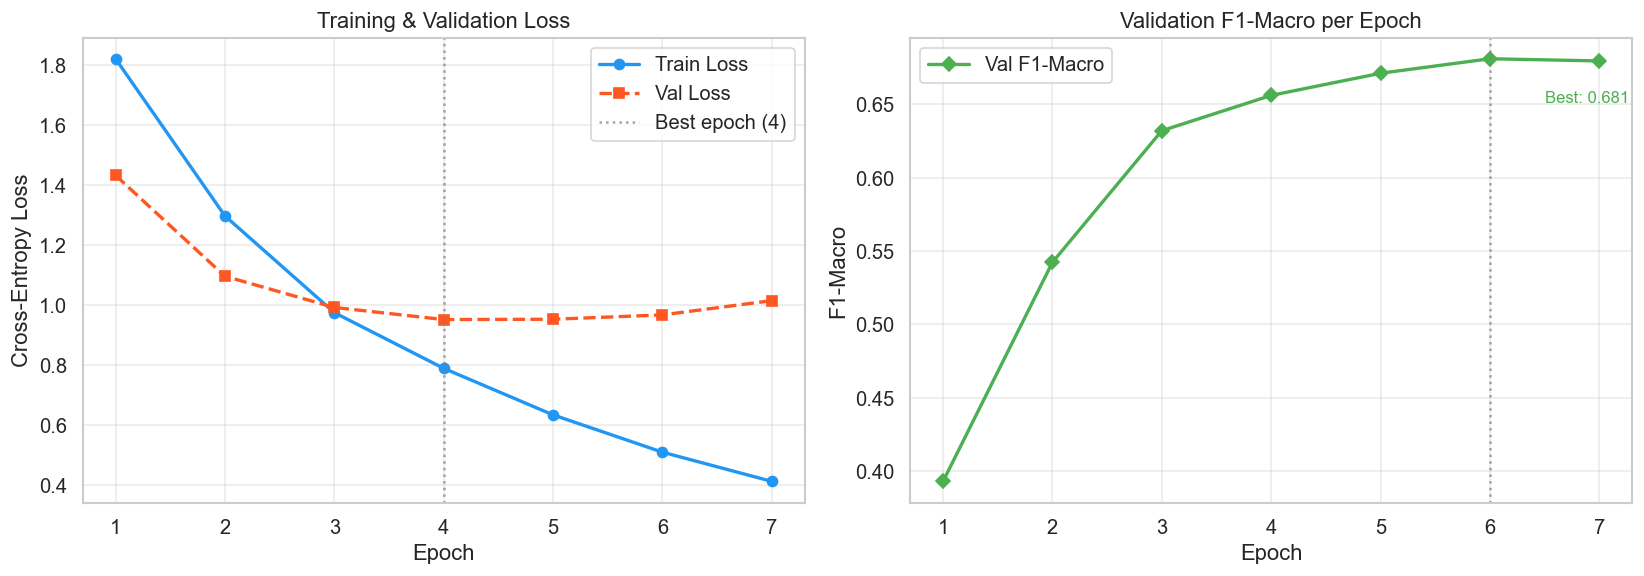

Best val_loss = 0.9520 (epoch 4)
Best val F1   = 0.6812 (epoch 6)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss curve ───────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(history_df["epoch"], history_df["train_loss"],
        marker="o", label="Train Loss", color="#2196F3", linewidth=2)
ax.plot(history_df["epoch"], history_df["val_loss"],
        marker="s", label="Val Loss",   color="#FF5722", linewidth=2, linestyle="--")

best_epoch = history_df["val_loss"].idxmin()
ax.axvline(x=history_df.loc[best_epoch, "epoch"], color="gray",
           linestyle=":", alpha=0.7, label=f"Best epoch ({history_df.loc[best_epoch,'epoch']})")

ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Training & Validation Loss")
ax.legend()
ax.grid(True, alpha=0.4)

# ── F1 curve ─────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(history_df["epoch"], history_df["val_f1_macro"],
        marker="D", color="#4CAF50", linewidth=2, label="Val F1-Macro")

best_f1_epoch = history_df["val_f1_macro"].idxmax()
best_f1 = history_df.loc[best_f1_epoch, "val_f1_macro"]
ax.axvline(x=history_df.loc[best_f1_epoch, "epoch"], color="gray",
           linestyle=":", alpha=0.7)
ax.annotate(f"Best: {best_f1:.3f}",
            xy=(history_df.loc[best_f1_epoch, "epoch"], best_f1),
            xytext=(history_df.loc[best_f1_epoch, "epoch"] + 0.5, best_f1 - 0.03),
            fontsize=10, color="#4CAF50")

ax.set_xlabel("Epoch")
ax.set_ylabel("F1-Macro")
ax.set_title("Validation F1-Macro per Epoch")
ax.legend()
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "learning_curves.png", bbox_inches="tight")
plt.show()
print(f"Best val_loss = {history_df['val_loss'].min():.4f} (epoch {history_df.loc[best_epoch,'epoch']})")
print(f"Best val F1   = {best_f1:.4f} (epoch {history_df.loc[best_f1_epoch,'epoch']})")

---
## 3. Confusion Matrix

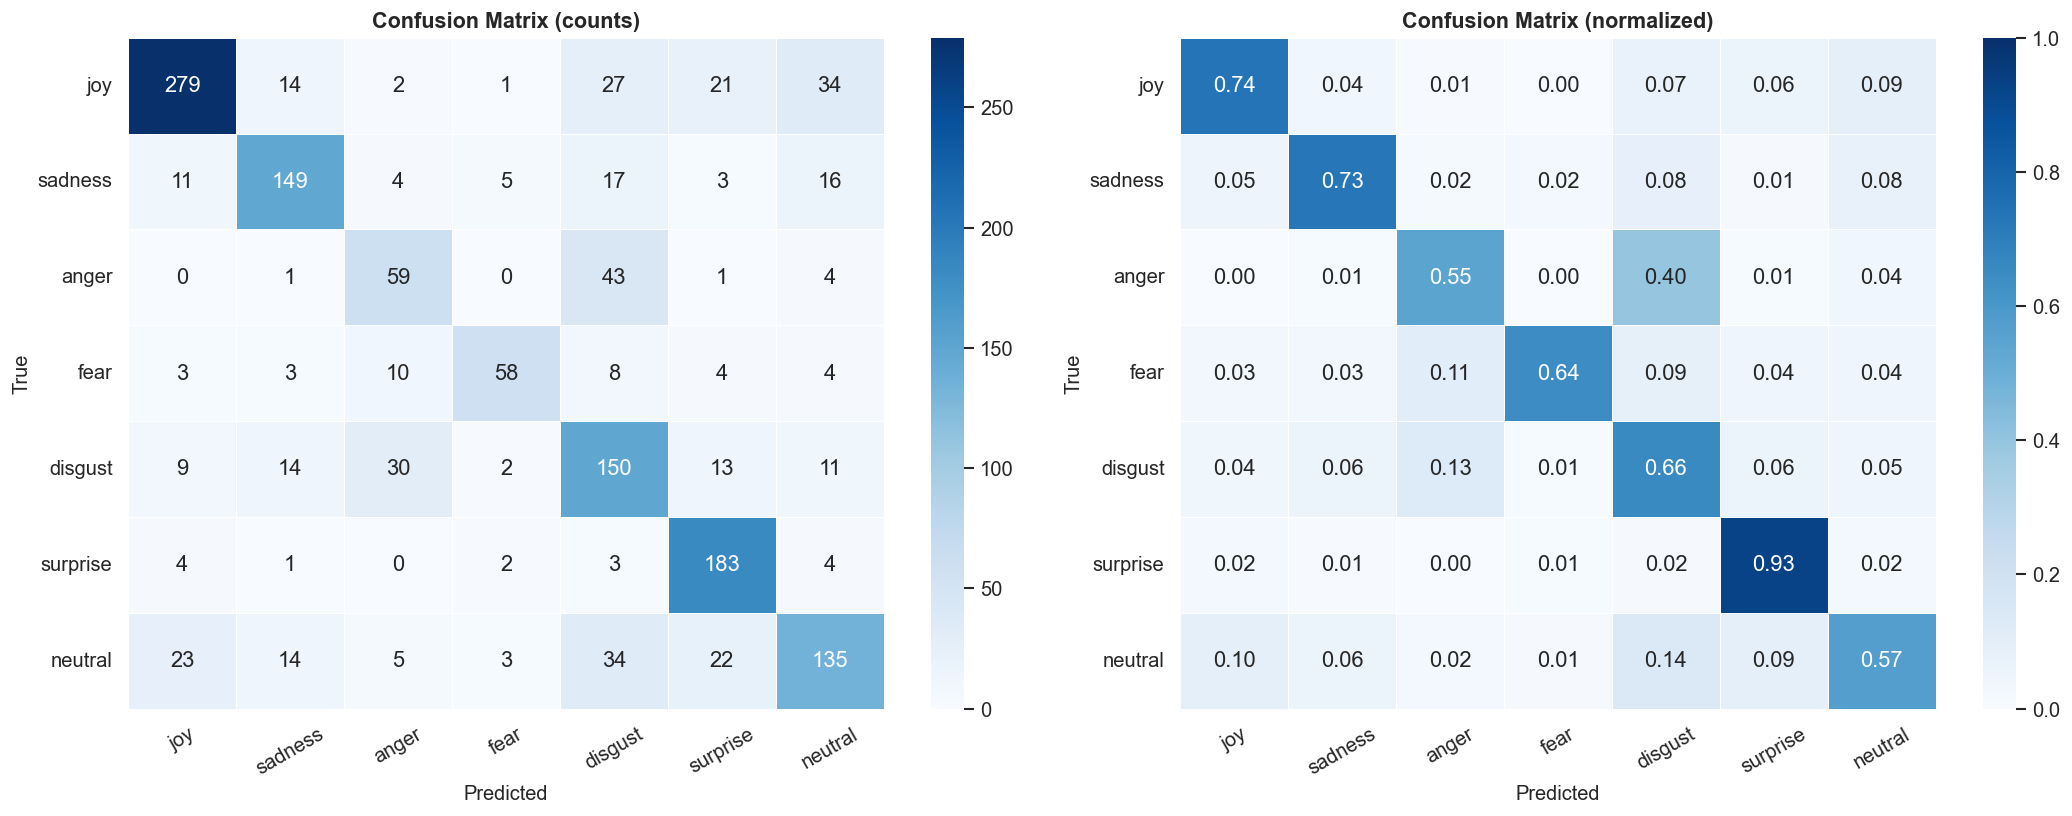


Test F1-Macro: 0.6877


In [7]:
y_true = preds_df["true_label"].tolist()
y_pred = preds_df["pred_label"].tolist()

cm = confusion_matrix(y_true, y_pred, labels=CLASS_NAMES)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalize

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, matrix, fmt, title, vmax in [
    (axes[0], cm,      "d",   "Confusion Matrix (counts)",    None),
    (axes[1], cm_norm, ".2f", "Confusion Matrix (normalized)", 1.0),
]:
    sns.heatmap(
        matrix, annot=True, fmt=fmt, cmap="Blues",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.5, vmax=vmax, ax=ax,
    )
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True", fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix.png", bbox_inches="tight")
plt.show()

f1_macro = f1_score(y_true, y_pred, labels=CLASS_NAMES, average="macro", zero_division=0)
print(f"\nTest F1-Macro: {f1_macro:.4f}")

---
## 4. Per-Class F1 Bar Chart

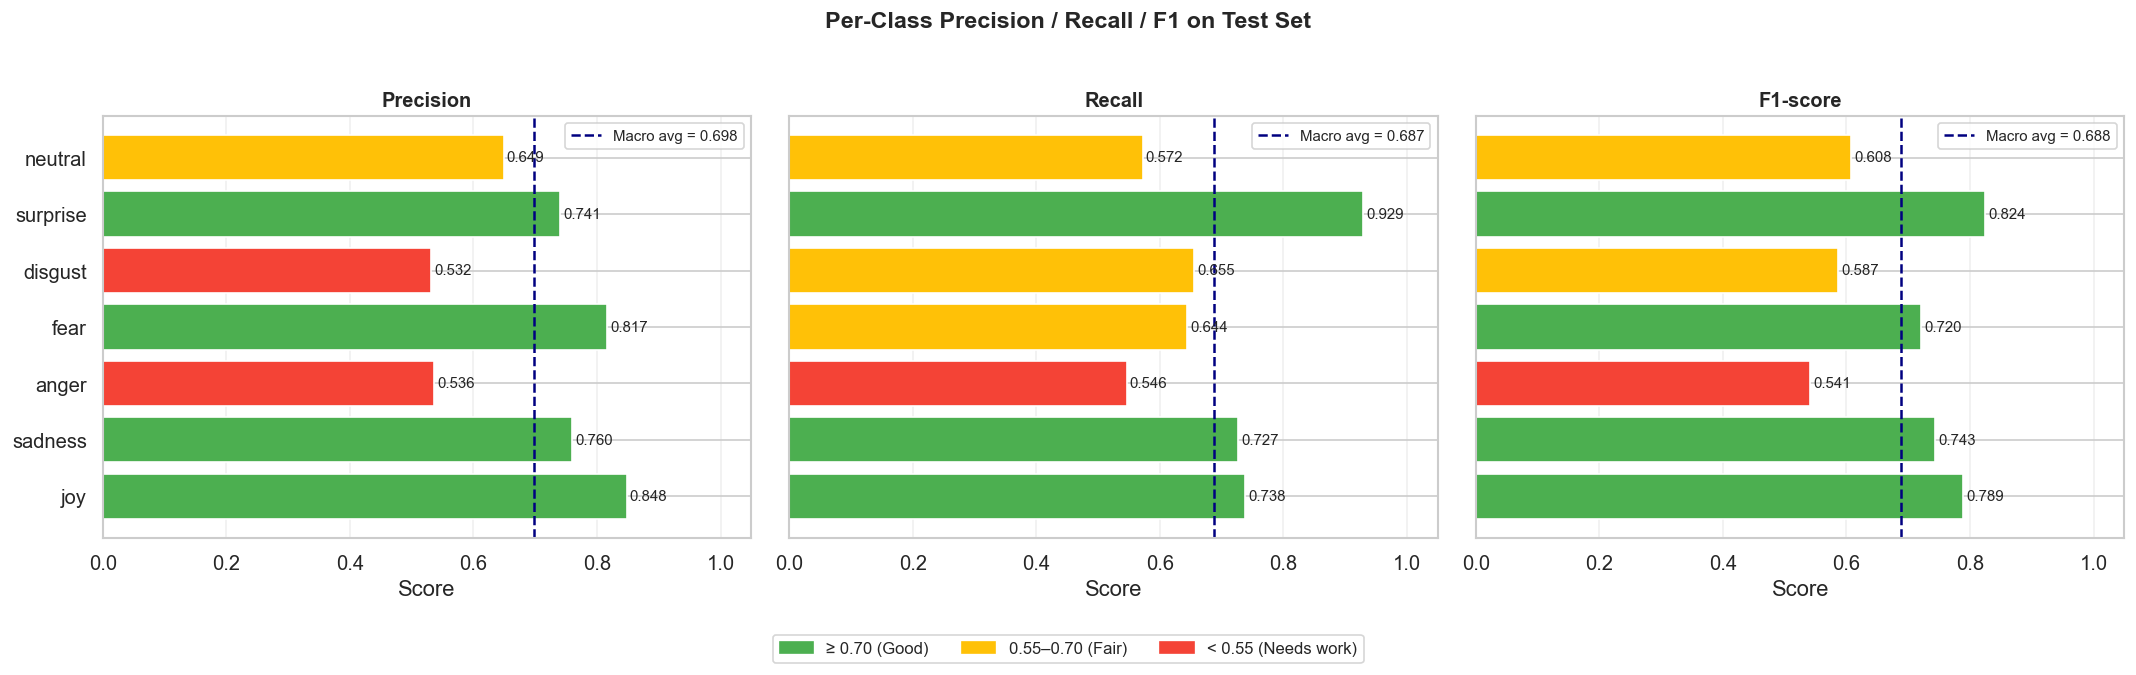


              precision    recall  f1-score   support

         joy       0.85      0.74      0.79       378
     sadness       0.76      0.73      0.74       205
       anger       0.54      0.55      0.54       108
        fear       0.82      0.64      0.72        90
     disgust       0.53      0.66      0.59       229
    surprise       0.74      0.93      0.82       197
     neutral       0.65      0.57      0.61       236

    accuracy                           0.70      1443
   macro avg       0.70      0.69      0.69      1443
weighted avg       0.71      0.70      0.70      1443



In [8]:
report = classification_report(
    y_true, y_pred, labels=CLASS_NAMES,
    output_dict=True, zero_division=0
)

per_class = pd.DataFrame(
    {cls: report[cls] for cls in CLASS_NAMES if cls in report}
).T.reset_index().rename(columns={"index": "emotion"})

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, metric in zip(axes, ["precision", "recall", "f1-score"]):
    colors = [
        "#4CAF50" if v >= 0.70 else "#FFC107" if v >= 0.55 else "#F44336"
        for v in per_class[metric]
    ]
    bars = ax.barh(per_class["emotion"], per_class[metric], color=colors, edgecolor="white")
    ax.axvline(x=report["macro avg"][metric], color="navy", linestyle="--",
               linewidth=1.5, label=f"Macro avg = {report['macro avg'][metric]:.3f}")
    for bar, val in zip(bars, per_class[metric]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)
    ax.set_xlim(0, 1.05)
    ax.set_title(metric.capitalize(), fontsize=12, fontweight="bold")
    ax.set_xlabel("Score")
    ax.legend(fontsize=9)
    ax.grid(axis="x", alpha=0.3)

legend_patches = [
    mpatches.Patch(color="#4CAF50", label="≥ 0.70 (Good)"),
    mpatches.Patch(color="#FFC107", label="0.55–0.70 (Fair)"),
    mpatches.Patch(color="#F44336", label="< 0.55 (Needs work)"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.08), fontsize=10)

plt.suptitle("Per-Class Precision / Recall / F1 on Test Set",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "per_class_metrics.png", bbox_inches="tight")
plt.show()

print("\n" + classification_report(y_true, y_pred, labels=CLASS_NAMES, zero_division=0))

---
## 5. Ablation Study Results

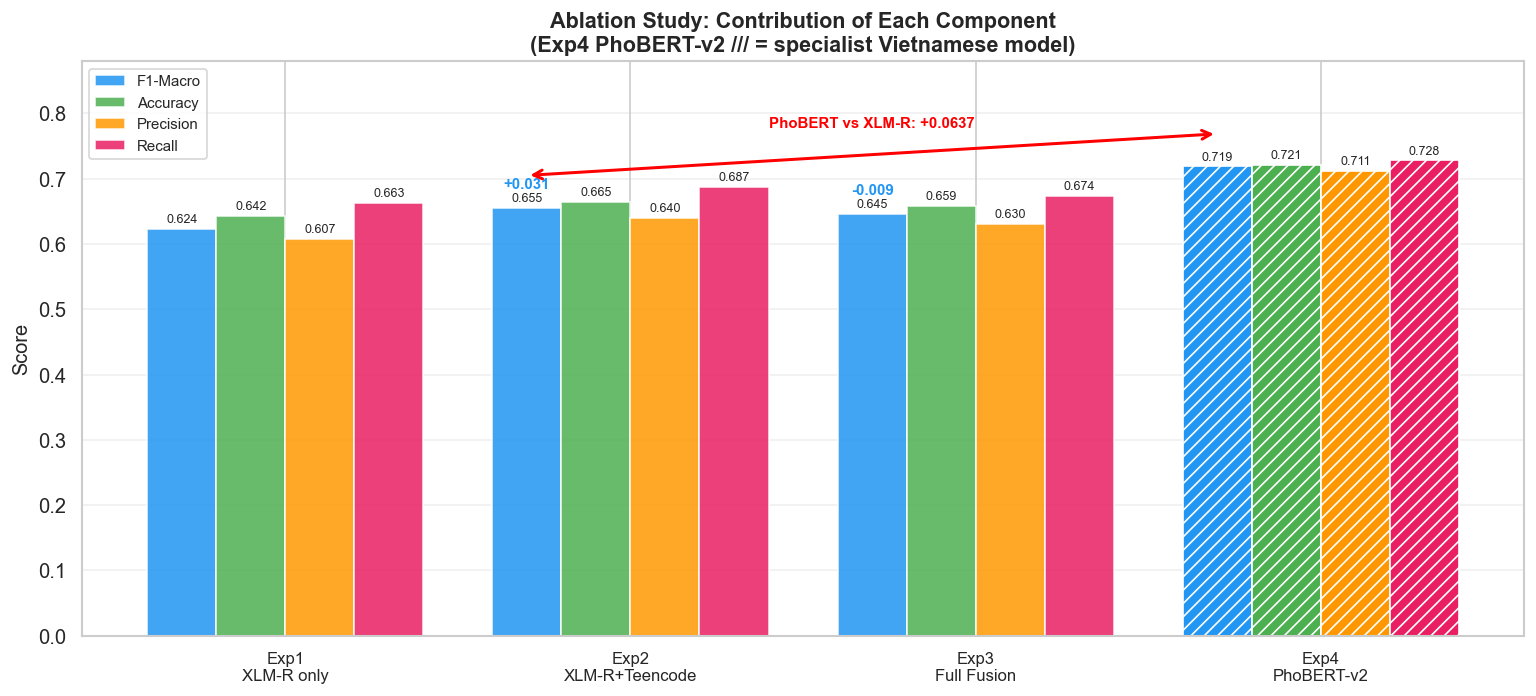


Ablation Table:
       display_label  f1_macro  accuracy  precision_macro  recall_macro
    Exp1\nXLM-R only  0.623546  0.642379         0.607224      0.662569
Exp2\nXLM-R+Teencode  0.654833  0.664684         0.640202      0.686923
   Exp3\nFull Fusion  0.645414  0.658736         0.630366      0.673851
    Exp4\nPhoBERT-v2  0.718550  0.721190         0.711213      0.727988


In [9]:
fig, ax = plt.subplots(figsize=(13, 6))

x       = np.arange(len(ablation_df))
width   = 0.2
metrics = ["f1_macro", "accuracy", "precision_macro", "recall_macro"]
colors  = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63"]
labels  = ["F1-Macro", "Accuracy", "Precision", "Recall"]

# PhoBERT bars get a hatched pattern to stand out
is_phobert = ablation_df["experiment"].str.contains("phobert").tolist()

for i, (metric, color, label) in enumerate(zip(metrics, colors, labels)):
    for j, (val, phobert) in enumerate(zip(ablation_df[metric], is_phobert)):
        hatch = "///" if phobert else ""
        bar = ax.bar(x[j] + i * width, val, width,
                     color=color, alpha=0.85 if not phobert else 1.0,
                     edgecolor="white", hatch=hatch,
                     label=label if j == 0 else "")
        ax.text(x[j] + i * width, val + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(ablation_df["display_label"], rotation=0, ha="center", fontsize=10)
ax.set_ylim(0, 0.88)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(
    "Ablation Study: Contribution of Each Component\n"
    "(Exp4 PhoBERT-v2 /// = specialist Vietnamese model)",
    fontsize=13, fontweight="bold"
)
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y", alpha=0.3)

# Annotate delta F1 between consecutive XLM-R experiments
f1_vals = ablation_df["f1_macro"].tolist()
exps    = ablation_df["experiment"].tolist()
for i in range(1, len(f1_vals)):
    if "phobert" not in exps[i]:   # only for XLM-R ablation chain
        delta = f1_vals[i] - f1_vals[i - 1]
        sign  = "+" if delta >= 0 else ""
        ax.annotate(
            f"{sign}{delta:.3f}",
            xy=(x[i], f1_vals[i] + 0.03),
            ha="center", fontsize=9, color="#2196F3", fontweight="bold"
        )

# Special annotation: PhoBERT vs XLM-R (Exp2) comparison
if "exp4_phobert" in exps and "exp2_xlmr_teencode" in exps:
    idx2 = exps.index("exp2_xlmr_teencode")
    idx4 = exps.index("exp4_phobert")
    delta_ph = f1_vals[idx4] - f1_vals[idx2]
    ax.annotate(
        "", xy=(x[idx4], f1_vals[idx4] + 0.05),
        xytext=(x[idx2], f1_vals[idx2] + 0.05),
        arrowprops=dict(arrowstyle="<->", color="red", lw=1.8)
    )
    mid_x = (x[idx2] + x[idx4]) / 2
    ax.text(mid_x, f1_vals[idx4] + 0.06,
            f"PhoBERT vs XLM-R: +{delta_ph:.4f}",
            ha="center", color="red", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ablation_results.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAblation Table:")
print(ablation_df[["display_label", "f1_macro", "accuracy", "precision_macro", "recall_macro"]].to_string(index=False))


---
## 6. Error Analysis — Sai nhiều nhất theo lớp

In [10]:
errors_df = preds_df[preds_df["true_label"] != preds_df["pred_label"]].copy()
errors_df["mistake"] = errors_df["true_label"] + " → " + errors_df["pred_label"]

print(f"Total errors: {len(errors_df)} / {len(preds_df)} ({len(errors_df)/len(preds_df)*100:.1f}%)")
print("\nMost common confusion pairs:")
print(errors_df["mistake"].value_counts().head(10).to_string())

Total errors: 430 / 1443 (29.8%)

Most common confusion pairs:
mistake
anger → disgust       43
joy → neutral         34
neutral → disgust     34
disgust → anger       30
joy → disgust         27
neutral → joy         23
neutral → surprise    22
joy → surprise        21
sadness → disgust     17
sadness → neutral     16


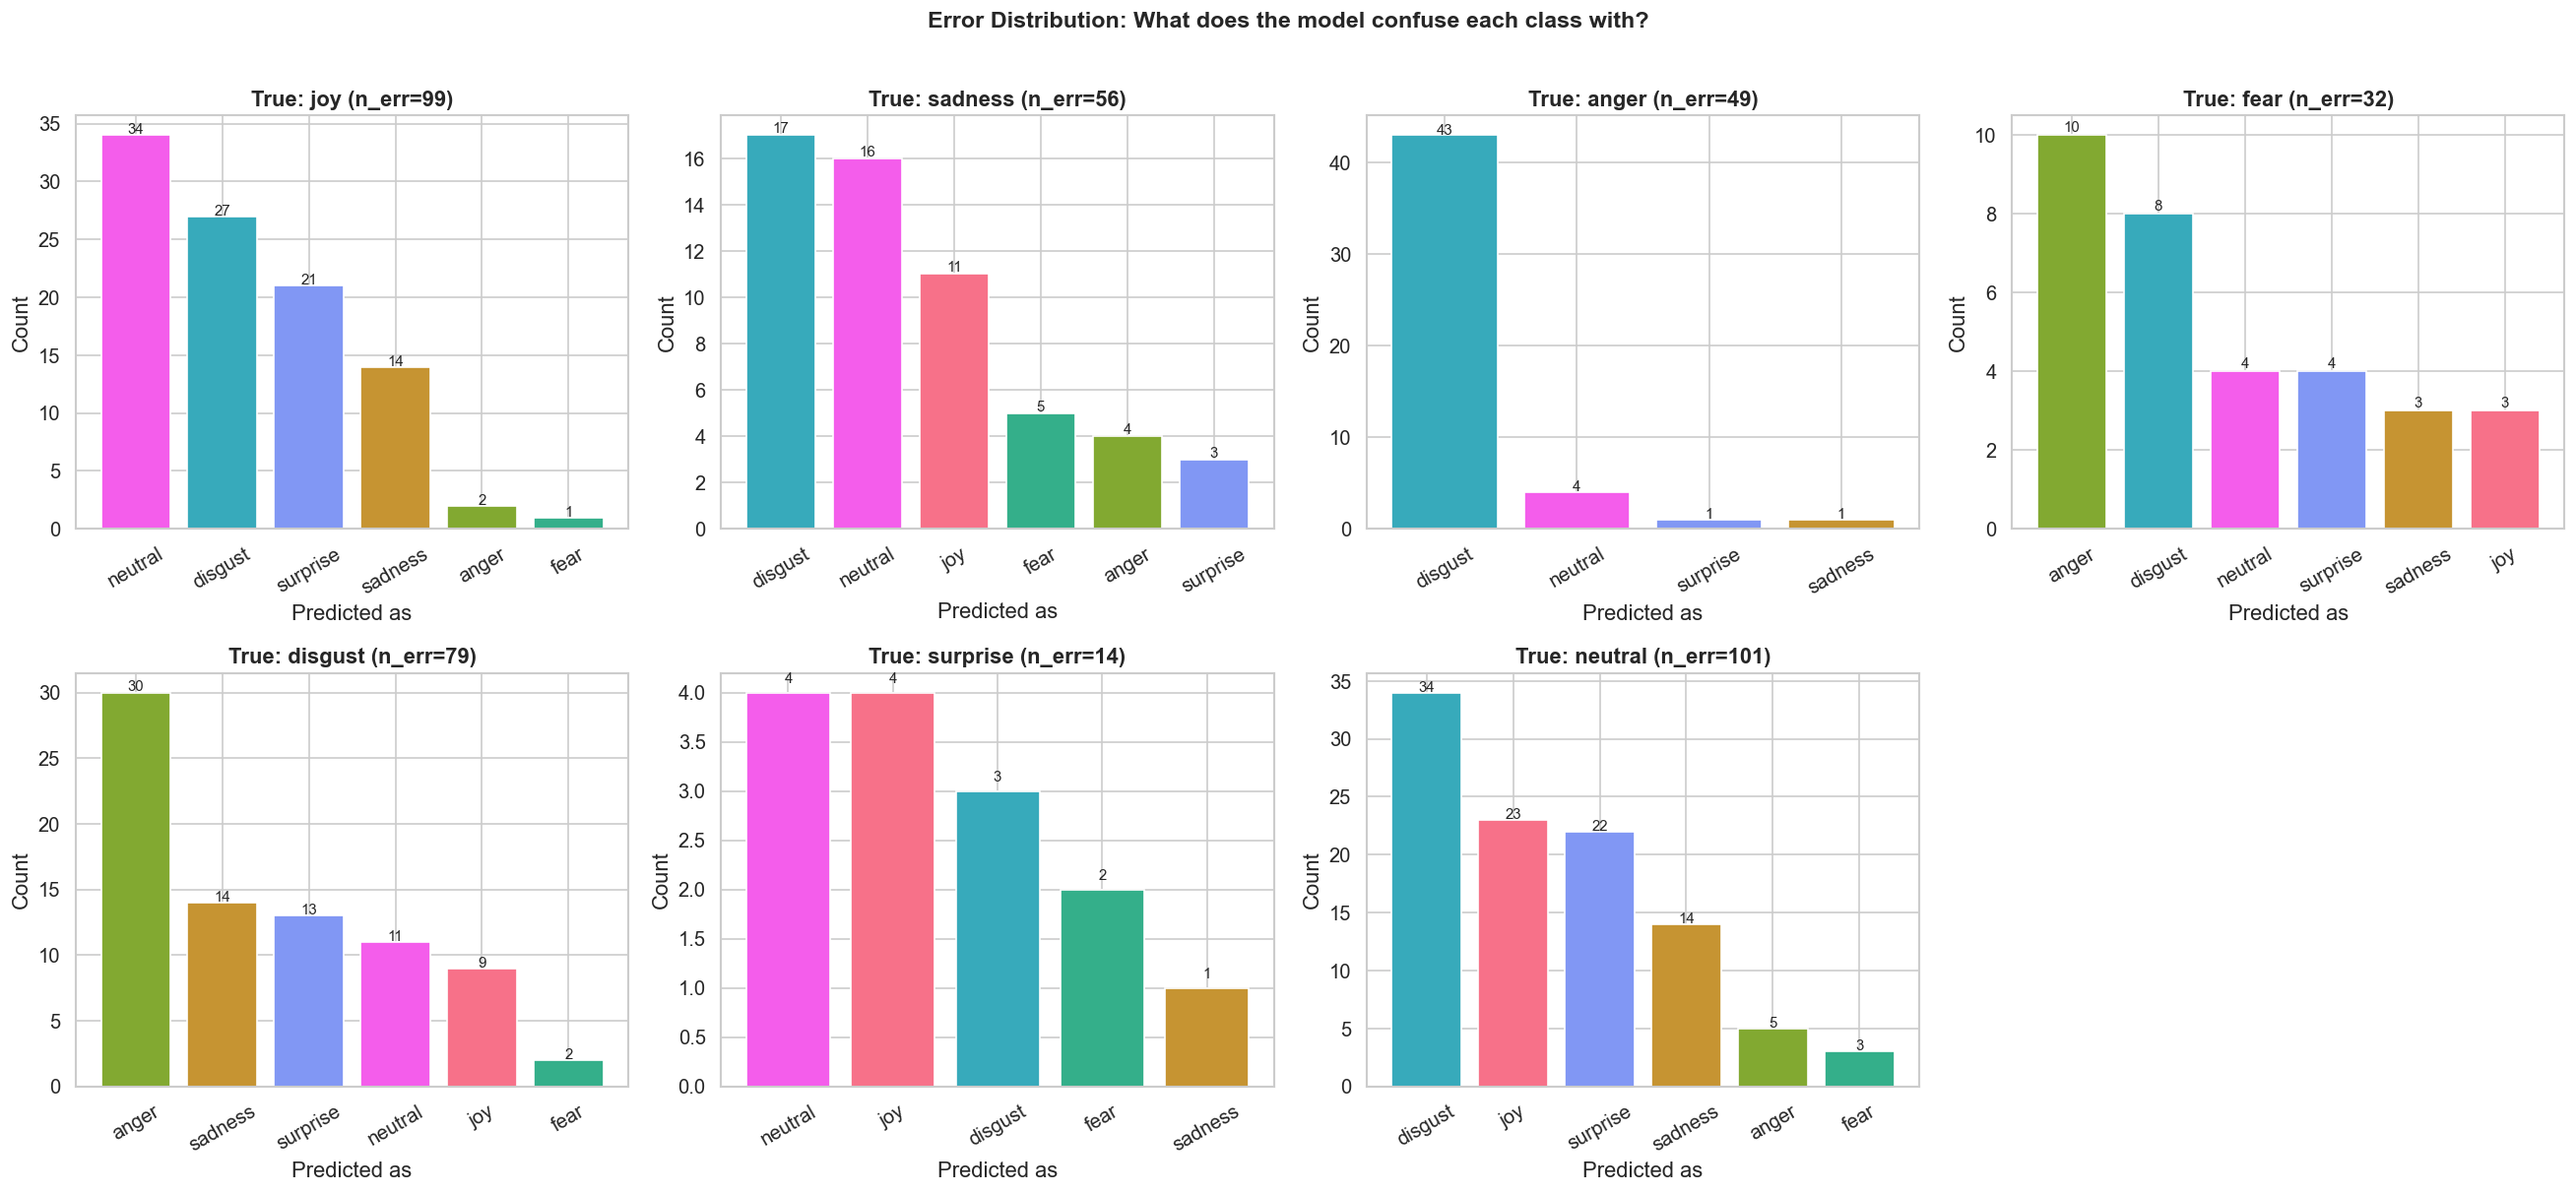

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for ax, cls in zip(axes, CLASS_NAMES):
    cls_errors = errors_df[errors_df["true_label"] == cls]
    if len(cls_errors) == 0:
        ax.text(0.5, 0.5, f"{cls}\n(no errors)",
                ha="center", va="center", transform=ax.transAxes, fontsize=11)
        ax.axis("off")
        continue

    mistake_counts = cls_errors["pred_label"].value_counts()
    colors_bar = [PALETTE[CLASS_NAMES.index(lbl)] for lbl in mistake_counts.index]
    bars = ax.bar(mistake_counts.index, mistake_counts.values,
                  color=colors_bar, edgecolor="white")
    for bar, val in zip(bars, mistake_counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                str(val), ha="center", fontsize=9)
    ax.set_title(f"True: {cls} (n_err={len(cls_errors)})", fontweight="bold")
    ax.set_xlabel("Predicted as")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)

axes[-1].axis("off")  # hide last empty subplot

plt.suptitle("Error Distribution: What does the model confuse each class with?",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "error_analysis.png", bbox_inches="tight")
plt.show()

In [12]:
# Show 3 most-confused examples per class
for cls in CLASS_NAMES:
    cls_errors = errors_df[errors_df["true_label"] == cls].head(3)
    if len(cls_errors) == 0:
        continue
    print(f"\n{'='*60}")
    print(f"True: {cls.upper()} — Top errors")
    print(f"{'='*60}")
    for _, row in cls_errors.iterrows():
        preview = str(row.get('text', ''))[:100]
        print(f"  Text:      {preview}")
        print(f"  Predicted: {row['pred_label']}")
        print()


True: JOY — Top errors
  Text:      :)) bật nhạc lên và quẩy thôi
  Predicted: neutral

  Text:      mẹ thằng này nói tiếng việt tốt thật lại còn nói được cả giọng phú yên nữa chứ
  Predicted: disgust

  Text:      kết nó ở cái câu " đất nước gia lai là một đất nước giàu tài nguyên , có anh per " [NEUTRAL]
  Predicted: neutral


True: SADNESS — Top errors
  Text:      per mệt quá mấy con ơi
  Predicted: neutral

  Text:      kiểu định share vì thấy tinh thần khá hơn nhưng đọc bình luận xong kiểu nhiều đứa còn tiêu cực hơn m
  Predicted: disgust

  Text:      tui thi ́ ch va ̉ i lă ́ mày ma ̀ ăn nhỉ ̀ u no ́ người lă ́ mày mọi người anh ̣ , bi ̣ lơ ̉ miê ̣ n
  Predicted: anger


True: ANGER — Top errors
  Text:      ngồi xa ra đụ mẹ mày :"))
  Predicted: disgust

  Text:      bao giờ mua bánh tặng gấu thì tao mới mua nhá . ở đấy mà chê tao bất hạnh
  Predicted: disgust

  Text:      per phá gia chi tử chính nó ?
  Predicted: surprise


True: FEAR — Top errors
  Text:      trích mà như 

---
## 7. LIME Explanation Examples

Chạy cell này sau khi model checkpoint đã được load thành công.

In [13]:
from IPython.display import HTML, display

CHECKPOINT = PROJECT_ROOT / "models" / "best_model"

if not (CHECKPOINT / "config.json").exists():
    print("⚠️  Model checkpoint not found — skipping LIME demo.")
    print(f"   Expected at: {CHECKPOINT}")
else:
    from app.inference import LateFusionPredictor
    from app.explainer import TextExplainer

    _CLASS_NAMES = ["joy", "sadness", "anger", "fear", "disgust", "surprise", "neutral"]
    predictor = LateFusionPredictor(
        checkpoint_dir=str(CHECKPOINT),
        class_names=_CLASS_NAMES,
        device="cpu",
    )
    explainer = TextExplainer(
        class_names=_CLASS_NAMES,
        predict_proba_fn=predictor.predict_proba,
        num_samples=150,
    )

    sample_texts = [
        "hôm nay vui quá luôn 😊 mọi việc đều suôn sẻ!",
        "tức vcl, sao làm ăn kiểu này, chán lắm rồi",
        "không biết gì luôn, sợ quá 😱",
        "đồ ăn dở tệ, ăn không được luôn",
        "ủa sao lại vậy được? bất ngờ thật!",
    ]

    for text in sample_texts:
        result = explainer.explain(text)
        print(f"\nText: {text}")
        print(f"Prediction: {result.label} ({result.confidence:.3f})")
        display(HTML(result.highlight_html))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Text: hôm nay vui quá luôn 😊 mọi việc đều suôn sẻ!
Prediction: joy (0.975)



Text: tức vcl, sao làm ăn kiểu này, chán lắm rồi
Prediction: anger (0.749)



Text: không biết gì luôn, sợ quá 😱
Prediction: fear (0.889)



Text: đồ ăn dở tệ, ăn không được luôn
Prediction: disgust (0.759)



Text: ủa sao lại vậy được? bất ngờ thật!
Prediction: surprise (0.967)


---
## 8. Summary — Bảng kết quả tổng hợp

In [14]:
summary = pd.DataFrame([
    {
        "Model":     row["display_label"].replace("\n", " "),
        "Backbone":  row.get("text_model", "xlm-roberta-base"),
        "F1-Macro":  f"{row['f1_macro']:.4f}",
        "Accuracy":  f"{row['accuracy']:.4f}",
        "Precision": f"{row['precision_macro']:.4f}",
        "Recall":    f"{row['recall_macro']:.4f}",
    }
    for _, row in ablation_df.iterrows()
])

print("=" * 95)
print("ABLATION RESULTS — ALL EXPERIMENTS")
print("=" * 95)
print(summary.to_string(index=False))
print("=" * 95)

best_exp = ablation_df.loc[ablation_df["f1_macro"].idxmax()]
print(f"\n✅ Best ablation model : {best_exp['display_label'].replace(chr(10), ' ')}")
print(f"   F1-Macro  = {best_exp['f1_macro']:.4f}")
print(f"   Accuracy  = {best_exp['accuracy']:.4f}")

# Compare PhoBERT vs XLM-R (Exp2)
if "exp4_phobert" in ablation_df["experiment"].values:
    exp2 = ablation_df[ablation_df["experiment"] == "exp2_xlmr_teencode"].iloc[0]
    exp4 = ablation_df[ablation_df["experiment"] == "exp4_phobert"].iloc[0]
    delta = exp4["f1_macro"] - exp2["f1_macro"]
    winner = "PhoBERT-v2" if delta > 0 else "XLM-RoBERTa"
    print(f"\n📊 PhoBERT (Exp4) vs XLM-R (Exp2): Δ={delta:+.4f} → {winner} thắng")


ABLATION RESULTS — ALL EXPERIMENTS
              Model              Backbone F1-Macro Accuracy Precision Recall
    Exp1 XLM-R only      xlm-roberta-base   0.6235   0.6424    0.6072 0.6626
Exp2 XLM-R+Teencode      xlm-roberta-base   0.6548   0.6647    0.6402 0.6869
   Exp3 Full Fusion      xlm-roberta-base   0.6454   0.6587    0.6304 0.6739
    Exp4 PhoBERT-v2 vinai/phobert-base-v2   0.7186   0.7212    0.7112 0.7280

✅ Best ablation model : Exp4 PhoBERT-v2
   F1-Macro  = 0.7186
   Accuracy  = 0.7212

📊 PhoBERT (Exp4) vs XLM-R (Exp2): Δ=+0.0637 → PhoBERT-v2 thắng
